<a href="https://colab.research.google.com/github/Rohanrathod7/my-ml-labs/blob/main/21_Intermediate_Deep_Learning_with_PyTorch/02_Images_%26_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 2. Images & Convolutional Neural Networks



Train neural networks to solve image classification tasks. In this chapter, you will learn how to handle image data in PyTorch and get to grips with convolutional neural networks (CNNs). You will practice training and evaluating an image classifier while learning about how to improve the model performance with data augmentation.

### Handling images with PyTorch

**Image dataset**  
Let's start with building a Torch Dataset of images. You'll use it to explore the data and, later, to feed it into a model.

The training data for the cloud classification task is stored in the following directory structure:

    clouds_train
      - cirriform clouds
        - 539cd1c356e9c14749988a12fdf6c515.jpg
        - ...
      - clear sky
      - cumulonimbus clouds
      - cumulus clouds
      - high cumuliform clouds
      - stratiform clouds
      - stratocumulus clouds
There are seven folders inside clouds_train, each representing one cloud type (or a clear sky). Inside each of these folders sit corresponding image files.

The following imports have already been done for you:

    from torchvision.datasets import ImageFolder
    from torchvision import transforms

In [ ]:
from torchvision import transforms
from torchvision.datasets import ImageFolder

# Compose transformations
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

# Create Dataset using ImageFolder
dataset_train = ImageFolder(
    'clouds_train',
    transform=train_transforms,
)

***Data augmentation***  
Data augmentation is used for training almost all image-based models. Understanding what it does (and what it doesn't) is crucial to using it effectively.

-> Data augmentation allows the model to learn from more examples of larger diversity, making it robust to real-world distortions. It tends to improve the model's performance, but it does not create more information than is already contained in the original images. If available, using more training data is preferred to creating it artificially with data augmentation!

- Using data augmentation allows the model to learn from more examples

- Using data augmentation increases the diversity of the training data

- Data augmentation makes the model more robust to variations and distortions commonly found in real-world images

- Data augmentation reduces the risk of overfitting as the model learns to ignore the random transformations

**Data augmentation in PyTorch**  
Let's include data augmentation in your Dataset and inspect some images visually to make sure the desired transformations are applied.

First, you'll add the augmenting transformations to train_transforms. Let's use a random horizontal flip and a rotation by a random angle between 0 and 45 degrees. The code that follows to create the Dataset and the DataLoader is exactly the same as before. Finally, you'll reshape the image and display it to see if the new augmenting transformations are visible.

All the imports you need have been called for you:

    from torchvision.datasets import ImageFolder
    from torch.utils.data import DataLoader
    from torchvision import transforms
    import matplotlib.pyplot as plt
    Time to augment some cloud photos!

In [ ]:
train_transforms = transforms.Compose([
    # Add horizontal flip and rotation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Resize((128, 128)),
])

dataset_train = ImageFolder(
  "clouds_train",
  transform=train_transforms,
)

dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=1
)

image, label = next(iter(dataloader_train))
# Reshape the image tensor
image = image.squeeze().permute(1, 2, 0)
# Display the image
plt.imshow(image)
plt.show()

# Can you see a frame of black pixels around it? That's the result of the image being rotated!
# The Dataset and DataLoaders you built in this lesson are ready to pass data to the cloud-classifying model

**Convolutional Neural Networks**

**The convolutional layer**  
Convolutional layers are the basic building block of most computer vision architectures. Understanding why they're used and how they work is crucial for building image-processing neural networks.

- Convolutional layers preserve spatial information between their inputs and outputs.

- Adding zero-padding around the convolutional layer's input ensures that the pixels at the border receive as much attention as those located elsewhere in the feature map.

- Convolutional layers in general use fewer parameters than linear layers.

**Building convolutional networks**  
You are on a team building a weather forecasting system. As part of the system, cameras will be installed at various locations to take pictures of the sky. Your task is to build a model to classify different cloud types in these pictures, which will help spot approaching weather fronts.

You decide to build a convolutional image classifier. The model will consist of two parts:

- A feature extractor that learns a vector of features from the input image,
- A classifier that predicts the image's class based on the learned features.

In [1]:
class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # Define feature extractor
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
        )
        # Define classifier
        self.classifier = nn.Linear(64*16*16, num_classes)

    def forward(self, x):
        # Pass input through feature extractor and classifier
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# You've built you first convolutional neural network for image classification!
# Most CNN architectures look similar: repeated blocks of convolution-activation-pooling with increasing number of feature maps,
# followed by a flatten and then one of more linear layers for classification or regression

NameError: name 'nn' is not defined

### Training image classifiers

**Choosing augmentations**  
You are building a model to recognize different flower species. You consider three augmentations to use: color shift, rotation, and texture change. The graphic below shows the examples of these three augmentations.

Image of a flower transformed in three ways: using rotation, color shift, and texture change.

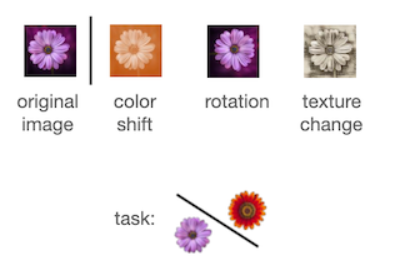

(image adapted from: https://arxiv.org/pdf/2008.05659.pdf)

Which of the augmentations could be used for the flower classifier?

- Only color shift  - Two flowers can sometimes only differ in petals color—changing the color might confuse the model!


- -- Only rotation - The flower is still the same species when it's rotated, so this augmentation will not introduce noise in training labels; rather, it will increase the diversity of the training samples!

- Only texture shift - Texture change could make one species of a flower look like a different one, confusing the model!


**Dataset with augmentations**  
You have already built the image dataset from cloud pictures and the convolutional model to classify different cloud types. Before you train it, let's adapt the dataset by adding the augmentations that could improve the model's cloud classification performance.

The code to set up the Dataset and DataLoader is already prepared for you and should look familiar. Your task is to define the composition of transforms that will be applied to the input images as they are loaded.

Note that before you were resizing images to 128 by 128 to display them nicely, but now you will use smaller ones to speed up training. As you will see later, 64 by 64 will be large enough for the model to learn.

In [ ]:
# Define transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(45),
    transforms.RandomAutocontrast(),
    transforms.ToTensor(),
    transforms.Resize((64*64)),
])

dataset_train = ImageFolder(
  "clouds_train",
  transform=train_transforms,
)
dataloader_train = DataLoader(
  dataset_train, shuffle=True, batch_size=16
)

**Image classifier training loop**  
It's time to train the image classifier! You will use the Net you defined earlier and train it to distinguish between seven cloud types.

To define the loss and optimizer, you will need to use functions from torch.nn and torch.optim, imported for you as nn and optim, respectively. You don't need to change anything in the training loop itself: it's exactly like the ones you wrote before, with some additional logic to print the loss during training.

In [ ]:
# Define the model
net = Net(num_classes=7)
# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
optimizer = optim.Adam(net.parameters(), lr=0.001)

for epoch in range(3):
    running_loss = 0.0
    # Iterate over training batches
    for images, labels in dataloader_train:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(dataloader_train)
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

# The training loss decreases, which means the model is learning! In the next lesson, you will evaluate the model's performance on a test set.

### **Evaluating image classifiers**

**Multi-class model evaluation**  
Let's evaluate our cloud classifier with precision and recall to see how well it can classify the seven cloud types. In this multi-class classification task it is important how you average the scores over classes. Recall that there are four approaches:

- Not averaging, and analyzing the results per class;
- Micro-averaging, ignoring the classes and computing the metrics globally;
- Macro-averaging, computing metrics per class and averaging them;
- Weighted-averaging, just like macro but with the average weighted by class size.

**Define precision and recall metrics calculated globally on all examples.**


In [ ]:
# Define metrics
metric_precision = Precision(task="multiclass", num_classes=7, average="micro")
metric_recall = Recall(task="multiclass", num_classes=7, average="micro")

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")

**Change your code to compute separate recall and precision metrics for each class and average them with a simple average.**

In [ ]:
# Define metrics
metric_precision = Precision(task="multiclass", num_classes=7, average="macro")
metric_recall = Recall(task="multiclass", num_classes=7, average="macro")

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
        metric_recall(preds, labels)

precision = metric_precision.compute()
recall = metric_recall.compute()
print(f"Precision: {precision}")
print(f"Recall: {recall}")

**Analyzing metrics per class**  
While aggregated metrics are useful indicators of the model's performance, it is often informative to look at the metrics per class. This could reveal classes for which the model underperforms.

In this exercise, you will run the evaluation loop again to get our cloud classifier's precision, but this time per-class. Then, you will map these score to the class names to interpret them

In [ ]:
# Define precision metric
metric_precision = Precision(
    task="multiclass", num_classes=7, average=None
)

net.eval()
with torch.no_grad():
    for images, labels in dataloader_test:
        outputs = net(images)
        _, preds = torch.max(outputs, 1)
        metric_precision(preds, labels)
precision = metric_precision.compute()

# Get precision per class
precision_per_class = {
    k: precision[v].item()
    for k, v
    in dataset_test.class_to_idx.items()
}
print(precision_per_class)

# It's not that surprising that the clear sky is the easiest to classify, but some cloud types are hard for the model to distinguish.
# Using larger images, more convolutional layers, and a classifier with more than one linear layer should improve the performance.